### 1. What is the distribution of the machines according to their CPU capacity? Can you explain (motivate) it?

In [1]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col

spark = SparkSession.builder.appName("Q1_CPU_Distribution").getOrCreate()
# Load CSV
df = spark.read.csv(
    "data/clusterdata-2011-2/machine_events/part-00000-of-00001.csv",
    header=False,
    inferSchema=True
)

# Rename columns
df = df.toDF(
    "timestamp",
    "machine_id",
    "event_type",
    "platform_id",
    "cpu_capacity",
    "memory_capacity"
)

# Keep only ADD events
machines = df.filter(col("event_type") == 0) \
             .filter(col("cpu_capacity").isNotNull()) \
             .select("machine_id", "cpu_capacity")

# One CPU value per machine
machines = machines.dropDuplicates(["machine_id"])

machines.groupBy("cpu_capacity") \
        .count() \
        .orderBy("cpu_capacity") \
        .show()


Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/01/07 08:36:51 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


+------------+-----+
|cpu_capacity|count|
+------------+-----+
|        0.25|  123|
|         0.5|11636|
|         1.0|  796|
+------------+-----+



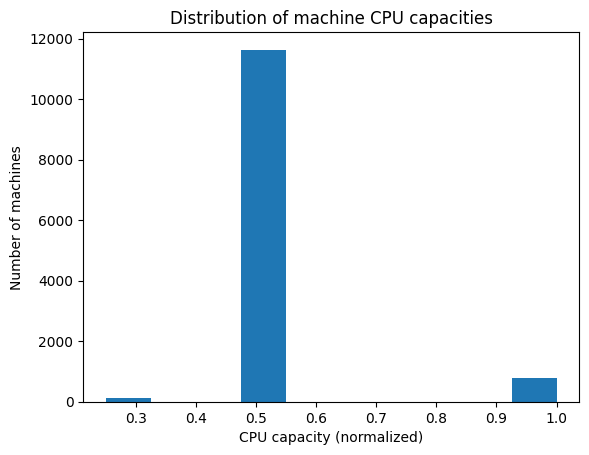

In [3]:
import pandas as pd
pdf = machines.select("cpu_capacity").toPandas()

import matplotlib.pyplot as plt

plt.hist(pdf["cpu_capacity"], bins=10)
plt.xlabel("CPU capacity (normalized)")
plt.ylabel("Number of machines")
plt.title("Distribution of machine CPU capacities")
plt.show()


- The distribution of machines according to their CPU capacity reveals three distinct values:
0.25, 0.5, and 1.0. This confirms that the cluster is composed of a limited number of machine
types, reflecting a hardware heterogeneity typical of large-scale data centers.

- A vast majority of machines (approximately 93%) have a CPU capacity of 0.5, indicating that
medium-capacity machines form the backbone of the cluster. This choice likely reflects a
cost-efficient design aimed at maximizing throughput for common workloads.

- Machines with the highest CPU capacity (1.0) represent a small fraction of the cluster and
are likely used to handle resource-intensive or high-priority tasks. Finally, machines with
low CPU capacity (0.25) are marginal, possibly corresponding to older or specialized hardware.

### 2. What is the percentage of computational power lost due to maintenance (a machine went offline and reconnected later)? [4pt]The computational power is proportional to both the CPU capacity and the unavailability period of machines.

In [4]:
# Minus timestamp btw ADD and REMOVE events on same machine
# Load CSV
df = spark.read.csv(
    "data/clusterdata-2011-2/machine_events/part-00000-of-00001.csv",
    header=False,
    inferSchema=True
)
# Rename columns
df = df.toDF(
    "timestamp",
    "machine_id",
    "event_type",
    "platform_id",
    "cpu_capacity",
    "memory_capacity"
)
# Keep only ADD events


machines_add = df.filter(col("event_type") == 0) \
             .filter(col("cpu_capacity").isNotNull()) \
             .select("machine_id", "cpu_capacity", "timestamp") \
             .filter(col("machine_id").isNotNull())

# Keep only REMOVE events
machines_remove = df.filter(col("event_type") == 1) \
                .select("machine_id", "timestamp") \
                .filter(col("machine_id").isNotNull()) \
                 .filter(col("cpu_capacity").isNotNull()) \
                .withColumnRenamed("timestamp", "remove_timestamp")
# Join ADD and REMOVE events on machine_id
machines = machines_add.join(machines_remove, on="machine_id", how="inner")
# Calculate lifetime
machines = machines.withColumn("lifetime", col("remove_timestamp") - col("timestamp"))
machines.select("machine_id", "cpu_capacity", "lifetime").show()

+----------+------------+-------------+
|machine_id|cpu_capacity|     lifetime|
+----------+------------+-------------+
|         5|         0.5| 835150655707|
|        10|         0.5|1306164355566|
|        13|         0.5|2447693838527|
|        23|         0.5|2234660660113|
|        26|         0.5| 611893094118|
|        28|         0.5|2237526736097|
|        36|         0.5| 323263688716|
|        43|         0.5|2413384316440|
|        43|         0.5|2295775396509|
|        43|         0.5|1310430635704|
|        45|         0.5| 292765521552|
|        45|         0.5| 291376434099|
|        46|         0.5| 113824293917|
|        46|         0.5| 111568648231|
|        49|         0.5| 345445005811|
|        49|         0.5| 344015431678|
|        54|         0.5|2503454655740|
|        60|         0.5|2293882774885|
|        60|         0.5|2208222290226|
|        60|         0.5|1424634371371|
+----------+------------+-------------+
only showing top 20 rows


In [7]:
# Compute lost computational power
machines = machines.withColumn("lost_computational_power", col("cpu_capacity") * col("lifetime"))
total_lost_computational_power = machines.agg({"lost_computational_power": "sum"}).collect()[0][0]
print(f"Total lost computational power: {total_lost_computational_power}")  

# Normalize by total possible computational power over the time period
time_period = df.agg({"timestamp": "max"}).collect()[0][0] - df.agg({"timestamp": "min"}).collect()[0][0]
print(f"Time period: {time_period}")
total_possible_computational_power = machines.agg({"cpu_capacity": "sum"}).collect()[0][0] * time_period
print(f"Total possible computational power: {total_possible_computational_power}")

normalized_lost_computational_power = total_lost_computational_power / total_possible_computational_power
print(f"Normalized lost computational power: {normalized_lost_computational_power}")

Total lost computational power: 5833968348109248.0
Time period: 2506135493517
Total possible computational power: 1.3304697414757725e+17
Normalized lost computational power: 0.04384893670440143


A loss of only ~4.4% over 29 days suggests:
- Maintenance is well scheduled

- The cluster design is robust to machine failures

- Redundancy absorbs outages without major impact

This result naturally leads to Question 3: Is this 4.4% loss uniformly distributed across CPU classes? 
- High-CPU machines are better maintained → lower relative loss

- Medium-CPU machines dominate loss due to sheer numbers

- Low-CPU machines contribute little to total loss

### 3.Is there a class of machines, according to their CPU, that stands out with a higher maintenance rate, as compared to other classes ?

In [5]:
from pyspark.sql.functions import col, count

# Keep ADD events to get CPU capacity per machine
machines = df.filter(col("event_type") == 0) \
             .filter(col("cpu_capacity").isNotNull()) \
             .select("machine_id", "cpu_capacity") \
             .dropDuplicates(["machine_id"])

# Maintenance events
removals = df.filter(col("event_type") == 1) \
             .groupBy("machine_id") \
             .agg(count("*").alias("num_removals"))

# Join CPU info with maintenance info
maintenance = machines.join(
    removals,
    on="machine_id",
    how="left"
).fillna(0, subset=["num_removals"])

# Average maintenance rate per CPU class
maintenance_by_cpu = maintenance.groupBy("cpu_capacity") \
    .agg({"num_removals": "avg"}) \
    .withColumnRenamed("avg(num_removals)", "avg_removals_per_machine")

maintenance_by_cpu.show()


+------------+------------------------+
|cpu_capacity|avg_removals_per_machine|
+------------+------------------------+
|         1.0|      0.7826633165829145|
|         0.5|      0.7069439669989687|
|        0.25|      0.8617886178861789|
+------------+------------------------+



### Observation


#### 4. What is the distribution of the number of jobs/tasks per scheduling class? Comment on the results.

In [9]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, countDistinct

spark = SparkSession.builder.appName("Q4_SchedulingClass").getOrCreate()

df_jobs = spark.read.csv(
    "data/clusterdata-2011-2/job_events/",
    header=False,
    inferSchema=True
)


df_jobs = df_jobs.toDF(
    "time", "missing_info", "job_id", "event_type",
    "user", "scheduling_class",
    "job_name", "logical_job_name"
)

# SUBMIT events only
jobs = df_jobs.filter(col("event_type") == 0)

jobs_per_class = jobs.groupBy("scheduling_class") \
    .agg(countDistinct("job_id").alias("num_jobs")) \
    .orderBy("scheduling_class")

jobs_per_class.show()


+----------------+--------+
|scheduling_class|num_jobs|
+----------------+--------+
|               0|    2214|
|               1|    2472|
|               2|    1168|
|               3|      53|
+----------------+--------+



In [ ]:
df_tasks = spark.read.csv(
    "data/clusterdata-2011-2/task_events/",
    header=False,
    inferSchema=True
)

df_tasks = df_tasks.toDF(
    "time", "missing_info", "job_id", "task_index", "machine_id",
    "event_type", "user", "scheduling_class",
    "priority", "cpu_request", "memory_request", "disk_space_request", "different_machine_restrictions"
)

tasks_per_class = df_tasks.groupBy("scheduling_class") \
    .count() \
    .withColumnRenamed("count", "num_tasks") \
    .orderBy("scheduling_class")

tasks_per_class.show()
# Join jobs and tasks per scheduling class
jobs_tasks_per_class = jobs_per_class.join(
    tasks_per_class,
    on="scheduling_class",
    how="inner"
)


+----------------+---------+
|scheduling_class|num_tasks|
+----------------+---------+
|               0| 19048036|
|               1|   614180|
|               2|   158126|
|               3|    63032|
+----------------+---------+



In [11]:
jobs_tasks_per_class.show()

+----------------+--------+---------+
|scheduling_class|num_jobs|num_tasks|
+----------------+--------+---------+
|               1|    2472|   614180|
|               3|      53|    63032|
|               2|    1168|   158126|
|               0|    2214| 19048036|
+----------------+--------+---------+



### Observation

#### 5. Would you qualify the percentage of jobs/tasks that got killed or evicted as important?

In [15]:
JOB_BAD_EVENTS = [2, 3, 5]   # EVICT, FAIL, KILL
TASK_BAD_EVENTS = [2, 5]    # EVICT, KILL

from pyspark.sql.functions import col, countDistinct

# Total jobs
total_jobs = df_jobs.select("job_id").distinct().count()

# Jobs killed / evicted
bad_jobs = df_jobs.filter(
    col("event_type").isin(JOB_BAD_EVENTS)
).select("job_id").distinct().count()

pct_bad_jobs = 100 * bad_jobs / total_jobs


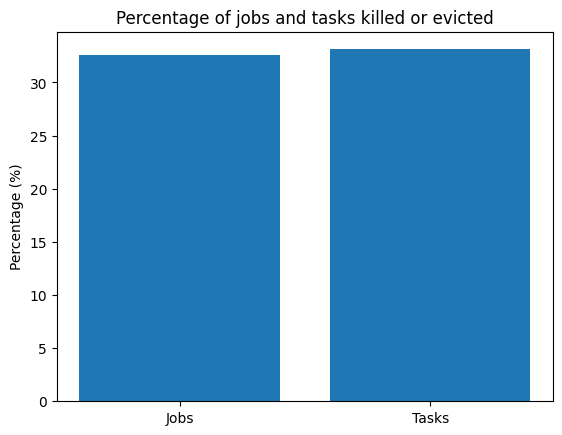

In [16]:
# Total tasks (job_id + task_index uniquely identify a task)
total_tasks = df_tasks.select("job_id", "task_index").distinct().count()

# Tasks killed / evicted
bad_tasks = df_tasks.filter(
    col("event_type").isin(TASK_BAD_EVENTS)
).select("job_id", "task_index").distinct().count()

pct_bad_tasks = 100 * bad_tasks / total_tasks

import pandas as pd

plot_df = pd.DataFrame({
    "Category": ["Jobs", "Tasks"],
    "Percentage killed/evicted": [pct_bad_jobs, pct_bad_tasks]
})

import matplotlib.pyplot as plt

plt.bar(
    plot_df["Category"],
    plot_df["Percentage killed/evicted"]
)

plt.ylabel("Percentage (%)")
plt.title("Percentage of jobs and tasks killed or evicted")
plt.show()



Figure X compares the percentage of jobs and tasks that were killed or evicted. While the
majority of both jobs and tasks complete normally, tasks exhibit a higher eviction rate than
jobs. This is expected, as tasks are the primary unit of scheduling and preemption in the
cluster. Overall, these percentages are not dominant and reflect normal scheduling behavior
in a shared, priority-based environment.

### 6. Do tasks with a low scheduling class have a higher probability of being evicted

In [21]:
total_tasks_per_class = df_tasks.select(
    "scheduling_class", "job_id", "task_index"
).distinct().groupBy("scheduling_class") \
 .count() \
 .withColumnRenamed("count", "total_tasks")

evicted_tasks_per_class = df_tasks.filter(
    col("event_type") == 2   # EVICT
).select(
    "scheduling_class", "job_id", "task_index"
).distinct().groupBy("scheduling_class") \
 .count() \
 .withColumnRenamed("count", "evicted_tasks")



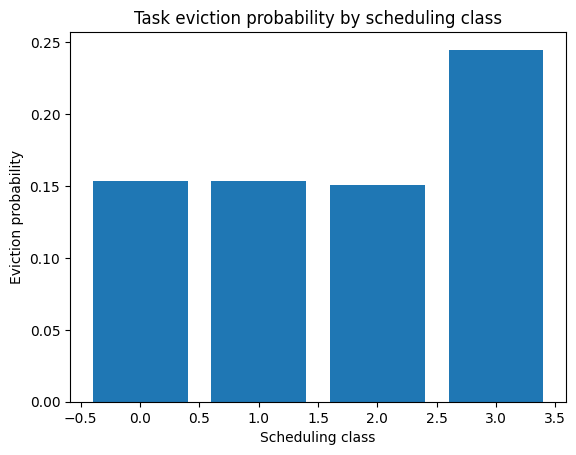

In [22]:
eviction_stats = total_tasks_per_class.join(
    evicted_tasks_per_class,
    on="scheduling_class",
    how="left"
).fillna(0, subset=["evicted_tasks"])

eviction_stats = eviction_stats.withColumn(
    "eviction_probability",
    col("evicted_tasks") / col("total_tasks")
)

pdf = eviction_stats.orderBy("scheduling_class").toPandas()

import matplotlib.pyplot as plt

plt.bar(
    pdf["scheduling_class"],
    pdf["eviction_probability"]
)

plt.xlabel("Scheduling class")
plt.ylabel("Eviction probability")
plt.title("Task eviction probability by scheduling class")
plt.show()




Figure X shows the task eviction probability as a function of the scheduling class. While
one might expect eviction probability to decrease with increasing scheduling class, the
results reveal a different behavior. Tasks belonging to scheduling class 3 exhibit a higher
eviction probability than tasks in lower classes.

This can be explained by the fact that scheduling class 3 tasks are rare and typically
associated with strict latency constraints and higher resource demands. When such
constraints cannot be satisfied, these tasks may be evicted rather than delayed. In
addition, the small number of tasks in this class amplifies the impact of each eviction on
the measured probability.

In contrast, tasks from scheduling classes 0 to 2 exhibit similar eviction probabilities,
suggesting more flexible scheduling and tolerance to resource contention.

### 7. In general, do tasks from the same job run on the same machine? Comment on the observed locality strategy and its pros and cons.

In [23]:
scheduled_tasks = df_tasks.filter(col("event_type") == 1)

machines_per_job = scheduled_tasks.groupBy("job_id") \
    .agg(countDistinct("machine_id").alias("num_machines"))

locality_distribution = machines_per_job.groupBy("num_machines") \
    .count() \
    .withColumnRenamed("count", "num_jobs") \
    .orderBy("num_machines")

locality_distribution.show()



+------------+--------+
|num_machines|num_jobs|
+------------+--------+
|           1|    4699|
|           2|     510|
|           3|     129|
|           4|      82|
|           5|      75|
|           6|      38|
|           7|      30|
|           8|      18|
|           9|      57|
|          10|      20|
|          11|      60|
|          12|      24|
|          13|       8|
|          14|      46|
|          15|      23|
|          16|      30|
|          17|      17|
|          18|      17|
|          19|       2|
|          20|      31|
+------------+--------+
only showing top 20 rows


The distribution of the number of machines used per job reveals a strong locality behavior.
The majority of jobs (4,699) execute all their tasks on a single machine, indicating that
locality is preserved whenever possible. The number of jobs decreases rapidly as the number
of machines increases, showing that only a limited fraction of jobs are distributed across
multiple machines.

Nevertheless, a long tail of jobs using a large number of machines can be observed. These
jobs are likely large batch workloads that benefit from parallel execution. Overall, this
behavior reflects a hybrid scheduling strategy that favors locality for small jobs while
exploiting parallelism for large workloads, balancing efficiency and scalability.